In [ ]:
# =========================
# CELL 1: Install libraries
# =========================
!pip -q install emoji beautifulsoup4 nltk scikit-learn pandas matplotlib seaborn sentence-transformers transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.5 MB/s eta 0:00:00


In [ ]:
# =========================
# CELL 2: Import libraries
# =========================
import os
import re
import html
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup
import emoji

import nltk
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
# =========================
# CELL 3: Load dataset
# =========================
# Option A: Upload manually in Colab
try:
    from google.colab import files
    uploaded = files.upload()
    if len(uploaded) > 0:
        DATA_PATH = list(uploaded.keys())[0]
    else:
        DATA_PATH = "Final dataset.csv"
except Exception:
    DATA_PATH = "Final dataset.csv"

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))
display(df.head())

Saving Final dataset.csv to Final dataset.csv
Dataset shape: (3070, 3)
Columns: ['text', 'polarity_score', 'sentiment']


,text,polarity_score,sentiment
0,The product is amazing and works as expected.,12,1
1,Delivery was delayed but product is good.,11,1
2,Worst experience ever do not buy!,2,2
3,Kuch khas nahi average hi tha.,7,0
4,Bahut accha laga mujhe pasand aaya.,13,1


Minimum class size: 547
Total samples after balancing: 1641


,Samples,Percentage
sentiment_label,,
Neutral,547,33.33
Negative,547,33.33
Positive,547,33.33


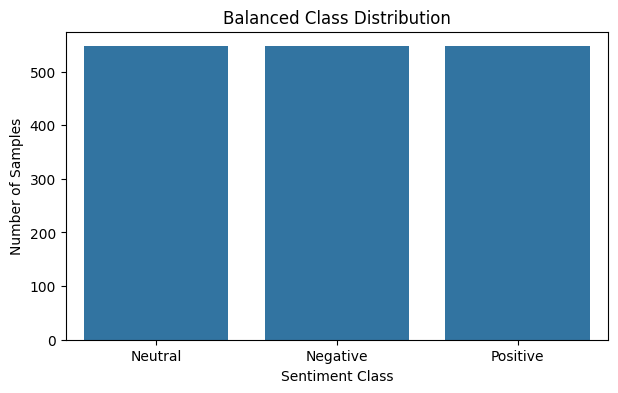

In [ ]:
# =========================
# CELL 6: Step 2 - Balance dataset (Undersampling)
# =========================

# Map numerical sentiment to labels
sentiment_map = {1: 'Positive', 0: 'Negative', 2: 'Neutral'}
df['sentiment_label'] = df['sentiment'].map(sentiment_map)

# Separate each class
df_pos = df[df["sentiment_label"] == "Positive"]
df_neu = df[df["sentiment_label"] == "Neutral"]
df_neg = df[df["sentiment_label"] == "Negative"]

# Find minimum class size
min_size = min(len(df_pos), len(df_neu), len(df_neg))

print("Minimum class size:", min_size)

# Perform undersampling
df_balanced = pd.concat([
    df_pos.sample(min_size, random_state=42),
    df_neu.sample(min_size, random_state=42),
    df_neg.sample(min_size, random_state=42)
])

# Shuffle dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Check new distribution
balanced_counts = df_balanced["sentiment_label"].value_counts()
balanced_percent = (balanced_counts / balanced_counts.sum() * 100).round(2)

balanced_summary = pd.DataFrame({
    "Samples": balanced_counts,
    "Percentage": balanced_percent
})

print("Total samples after balancing:", len(df_balanced))
display(balanced_summary)

# Plot
plt.figure(figsize=(7, 4))
sns.barplot(x=balanced_summary.index, y=balanced_summary["Samples"])
plt.title("Balanced Class Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Samples")
plt.show()

In [ ]:
df_balanced.head()

,text,polarity_score,sentiment,sentiment_label
0,not good at all\n34 fit dure gelei connection ...,4,2,Neutral
1,Movie par mila audience ka mixed reaction kuch...,6,0,Negative
2,Service is unreliable and inconsistent.,3,2,Neutral
3,Promises for resolution never materialized.,3,2,Neutral
4,Post mein thodi hatt ke baatein thi Australia.,7,0,Negative


In [ ]:
# =========================
# CELL 7: Save & Download Balanced Dataset
# =========================

# Save to CSV
file_name = "balanced_dataset.csv"
df_balanced.to_csv(file_name, index=False)

print("File saved as:", file_name)

# Download file (Colab)
from google.colab import files
files.download(file_name)

File saved as: balanced_dataset.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>